| Cell type        | Description |
|------------------|------------|
| **Basophil** | Basophils play a role in allergic and parasitic reactions by releasing histamine and heparin. In leukemia, elevated basophils may indicate chronic myeloid leukemia (CML) or, in rare cases, proliferate in basophilic leukemia. |
| **Erythroblast** | Erythroblasts are precursor cells of red blood cells that mature in the bone marrow and transport oxygen. In leukemias such as erythroleukemia (AML M6), abnormal erythroblasts displace normal hematopoiesis and cause anemia. |
| **Eosinophil** | Eosinophils combat parasites and modulate allergic reactions through granule release. In leukemia, they appear in eosinophilic leukemias or AML M4Eo, where genetic aberrations cause proliferation and can influence prognosis. |
| **Smudge cell** | Smudge cells form from the breakdown of lymphocytes during blood smear preparation and are fragile. They are characteristic of chronic lymphocytic leukemia (CLL), where they reflect massive lymphocyte accumulation and have diagnostic significance. |
| **Lymphocyte** | Lymphocytes are central immune cells for adaptive immunity (B, T, and NK cells). In lymphoid leukemias such as ALL or CLL, malignant lymphocytes proliferate uncontrollably and suppress normal immune function. |
| **Metamyelocyte** | Metamyelocytes are immature granulocyte precursors on the path to neutrophil maturation. In acute myeloid leukemia (AML), they appear in the blood as a sign of incomplete differentiation and contribute to leukocytosis. |
| **Monoblast** | Monoblasts are the earliest precursors of monocytes and macrophages in the bone marrow. In AML M5 (monoblastic leukemia), they predominate and lead to monocytosis with a high tendency to infiltrate tissues. |
| **Monocyte** | Monocytes differentiate into macrophages and dendritic cells responsible for phagocytosis and antigen presentation. In myelomonocytic leukemia (AML M4/M5), malignant monocytes increase and promote tissue destruction. |
| **Myelocyte** | Myelocytes are precursors of granulocytes (neutrophils, eosinophils, basophils) within the myeloid maturation chain. In chronic myeloproliferative diseases or AML, they appear in peripheral blood and signal disturbed hematopoiesis. |
| **Myeloblast** | Myeloblasts are pluripotent precursor cells of all myeloid lineages in the bone marrow. In AML (e.g., M1/M2), they exceed 20% and block maturation, leading to severe leukopenia and susceptibility to infections. |
| **Neutrophil** | Neutrophils are key players in acute immune defense against bacteria through phagocytosis and NETosis. In AML or CML, abnormal neutrophils can impair function and cause neutropenia with an increased risk of infection. |
| **Promyelocyte** | Promyelocytes are early granulocyte precursors with azurophilic granules. In acute promyelocytic leukemia (APL, AML M3), they accumulate due to the t(15;17) translocation and cause coagulation disorders. |


| Abbreviation | Morphological Class Description                               |
| ------------ | ------------------------------------------------------------- |
| BAS          | Basophil                                                      |
| EBO          | Erythroblast                                                  |
| EOS          | Eosinophil                                                    |
| KSC          | Smudge cell                                                   |
| LYA          | Lymphocyte (atypical)                                         |
| LYT          | Lymphocyte (typical)                                          |
| MMZ          | Metamyelocyte                                                 |
| MOB          | Monoblast                                                     |
| MON          | Monocyte                                                      |
| MYB          | Myelocyte                                                     |
| MYO          | Myeloblast                                                    |
| NGB          | Neutrophil (band)                                             |
| NGS          | Neutrophil (segmented)                                        |
| PMB          | Promyelocyte (bilobled)                                       |
| PMO          | Promyelocyte                                                  |
| UNC          | Image that could not be assigned a class during re-annotation |
| nan          | No re-annotation                                              |

In [23]:
import os
from pathlib import Path
import re
from PIL import Image
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [26]:

ROOT_DIR = Path.cwd() / "Data" / "LeukemiaCells" / "PKG_AML_Cytomorphology_LMU"
MAX_IMAGES_PER_CLASS = 10000

IMG_EXTS = {".jpg", ".jpeg",".tiff"}


Class distribution:
cell type  count  percentage
      NGS   8484   46.196570
      LYT   3937   21.437517
      MYO   3268   17.794718
      MON   1789    9.741356
      EOS    424    2.308739
      NGB    109    0.593520
      BAS     79    0.430166
      EBO     78    0.424721
      PMO     70    0.381160
      MYB     42    0.228696
      MOB     26    0.141574
      PMB     18    0.098013
      KSC     15    0.081677
      MMZ     15    0.081677
      LYA     11    0.059897


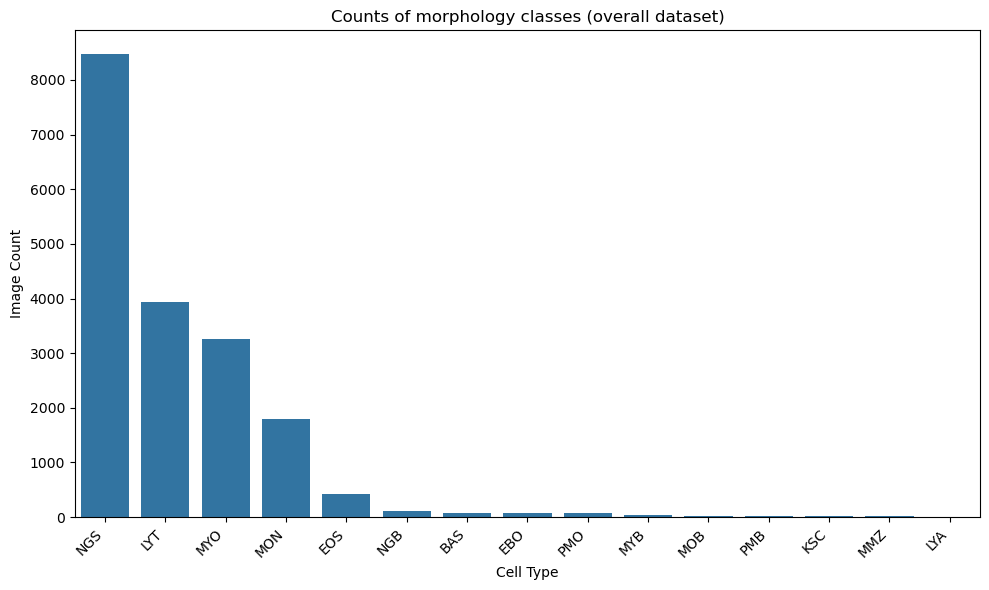

In [ ]:


class_counts = {}

for subfolder in ROOT_DIR.iterdir():
    if not subfolder.is_dir():
        continue
    class_name = subfolder.name
    img_files = [
        f for f in subfolder.iterdir()
        if f.is_file() and f.suffix.lower() in IMG_EXTS
    ]
    class_counts[class_name] = len(img_files)

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["cell type", "count"]
)

df_counts = df_counts.sort_values("count", ascending=False).reset_index(drop=True)

df_counts["percentage"] = 100 * df_counts["count"] / df_counts["count"].sum()

print("\nClass distribution:")
print(df_counts.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=df_counts, x="cell type", y="count")
plt.title("Counts of morphology classes (overall dataset)")
plt.xlabel("Cell Type")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [4]:
df_annot1 = pd.read_csv('Data/LeukemiaCells/annotations.dat', sep=r'\s+',header=None)  # oder sep=r'\s+' für Leerzeichen
df_annot1.columns = ['filename', 'annotation_1', 'annotation_2', 'annotation_3']
df_annot1.head()
df_annot2 = df_annot1.dropna(subset=['annotation_2'])

df_annot2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1905 entries, 20 to 18355
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   filename      1905 non-null   object
 1   annotation_1  1905 non-null   object
 2   annotation_2  1905 non-null   object
 3   annotation_3  1905 non-null   object
dtypes: object(4)
memory usage: 74.4+ KB


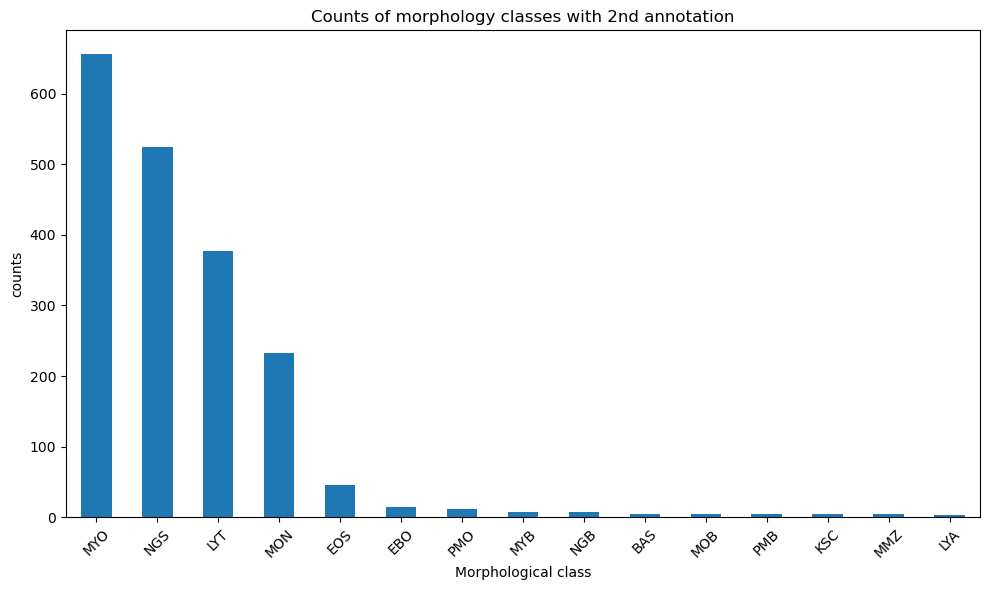

In [14]:
plt.figure(figsize=(10, 6))
df_annot2['annotation_1'].value_counts().plot(kind='bar')#, figsize=(10,6))
plt.title('Counts of morphology classes with 2nd annotation')
plt.xlabel('Morphological class')
plt.ylabel('counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
crosstab12 = pd.crosstab(df_annot2['annotation_1'], df_annot2['annotation_2'])
crosstab13 = pd.crosstab(df_annot2['annotation_1'], df_annot2['annotation_3'])
crosstab23 = pd.crosstab(df_annot2['annotation_2'], df_annot2['annotation_3'])


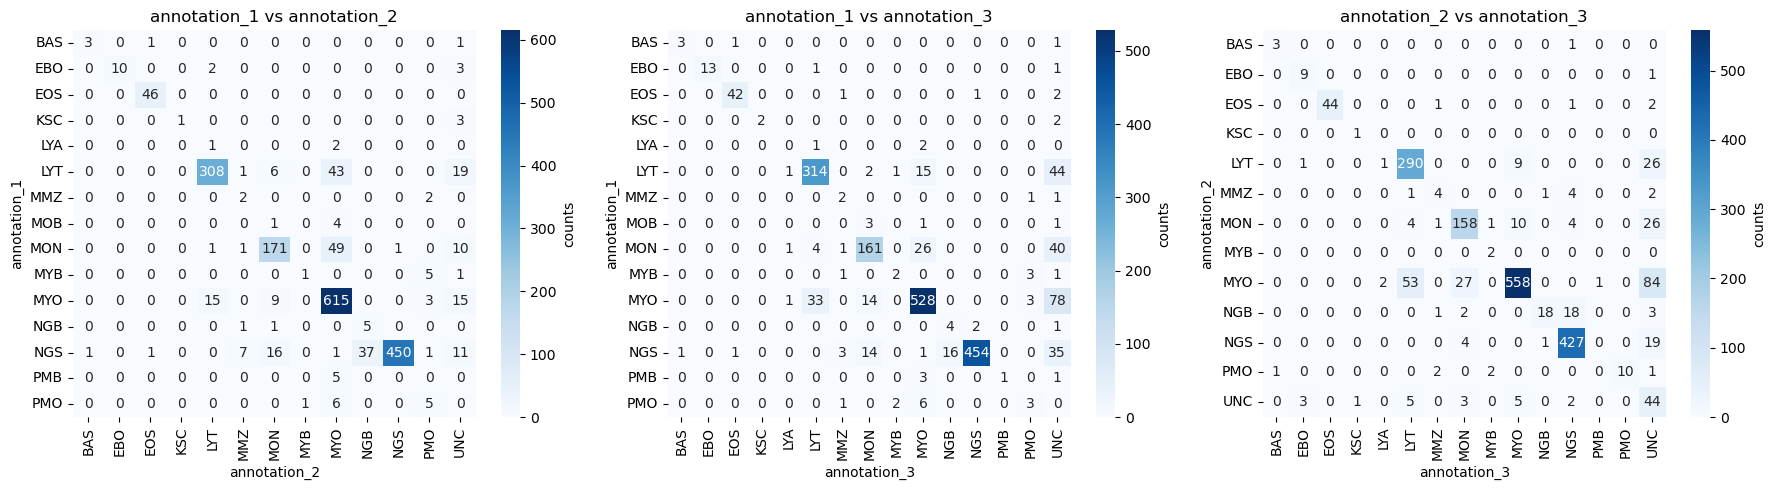

In [10]:
colmap = 'Blues'
plt.figure(figsize=(18, 5))
plt.subplot(131)
sns.heatmap(crosstab12, annot=True, fmt='d', cmap=colmap, 
            cbar_kws={'label': 'counts'})
plt.title('annotation_1 vs annotation_2')

plt.subplot(132)
sns.heatmap(crosstab13, annot=True, fmt='d', cmap=colmap, 
            cbar_kws={'label': 'counts'})
plt.title('annotation_1 vs annotation_3')

plt.subplot(133)
sns.heatmap(crosstab23, annot=True, fmt='d', cmap=colmap, 
            cbar_kws={'label': 'counts'})
plt.title('annotation_2 vs annotation_3')

plt.tight_layout()
plt.show()

In [12]:
pattern = re.compile(r'^([A-Za-z]+)_(\d+)\.tiff$')

rows = []
for dirpath, dirnames, filenames in os.walk(ROOT_DIR):
    for fname in filenames:
        m = pattern.match(fname)
        if not m:
            continue  
        abbrev = m.group(1)
        folder = Path(dirpath).name 
        rows.append({
            'filename': fname,
            'abb_class': abbrev,
            'folder': folder,
        })

df_NC = pd.DataFrame(rows, columns=['filename', 'abb_class', 'folder'])
df_NC.head()

,filename,abb_class,folder
0,KSC_0005.tiff,KSC,KSC
1,KSC_0013.tiff,KSC,KSC
2,KSC_0009.tiff,KSC,KSC
3,KSC_0008.tiff,KSC,KSC
4,KSC_0012.tiff,KSC,KSC


/var/folders/yb/0_1pj82935q25kz775_hfns40000gn/T/ipykernel_2895/656086642.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_NC.groupby('abb_class').apply(lambda x: x.sample(n=3, random_state=42)).reset_index(drop=True)


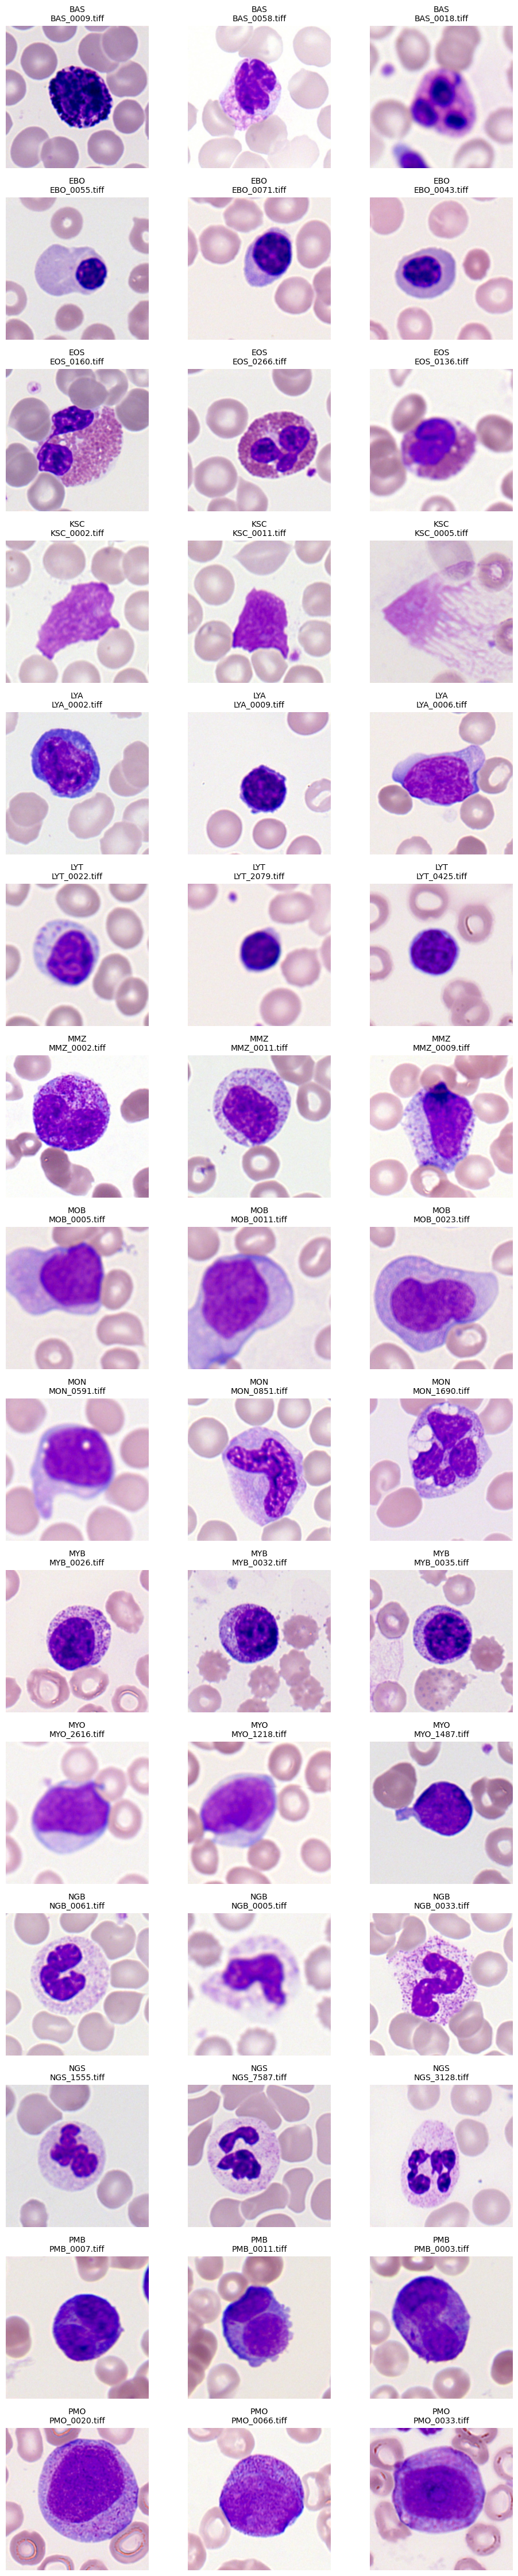

In [ ]:

sampled_df = df_NC.groupby('abb_class').apply(lambda x: x.sample(n=3, random_state=42)).reset_index(drop=True)

classes = sampled_df['abb_class'].unique()
n_classes = len(classes)
fig, axes = plt.subplots(n_classes, 3, figsize=(10, 3 * n_classes))

if n_classes == 1:
    axes = axes.reshape(1, -1)

for i, cls in enumerate(classes):
    class_samples = sampled_df[sampled_df['abb_class'] == cls]
    
    for j, (_, row) in enumerate(class_samples.iterrows()):
        img_path = os.path.join(ROOT_DIR, row['folder'], row['filename'])
        
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].set_title(f"{row['abb_class']}\n{row['filename']}", fontsize=10)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:


def analyze_image_rgb(img_path):
    try:
        img = Image.open(img_path)
        if img.mode != "RGB":
            img = img.convert("RGB")
        arr = np.array(img).astype(np.float32)  # [H, W, 3]

        gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
        mean_intensity = np.mean(gray)
        std_intensity = np.std(gray)

        r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
        stats = {
            "mean_r": np.mean(r),
            "std_r": np.std(r),
            "min_r": np.min(r),
            "max_r": np.max(r),
            "mean_g": np.mean(g),
            "std_g": np.std(g),
            "min_g": np.min(g),
            "max_g": np.max(g),
            "mean_b": np.mean(b),
            "std_b": np.std(b),
            "min_b": np.min(b),
            "max_b": np.max(b),
        }

        return mean_intensity, std_intensity, stats
    except Exception as e:
        print(f"Fehler beim Lesen von {img_path}: {e}")
        return np.nan, np.nan, {}


In [ ]:

results = []

for class_name in os.listdir(ROOT_DIR):
    class_path = os.path.join(ROOT_DIR, class_name)
    if not os.path.isdir(class_path):
        continue

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff"))
    ]

    sampled_files = random.sample(
        image_files,
        min(MAX_IMAGES_PER_CLASS, len(image_files))
    )

    for img_file in sampled_files:
        img_path = os.path.join(class_path, img_file)
        mean_int, std_int, rgb_stats = analyze_image_rgb(img_path)

        row = {
            "class": class_name,
            "filename": img_file,
            "mean_intensity": mean_int,
            "std_intensity": std_int,
        }
        row.update(rgb_stats)
        results.append(row)


df = pd.DataFrame(results)








Farbstatistik pro Klasse (RGB‑Mittelwerte):
           mean_r      mean_g      mean_b
class                                    
BAS    207.249756  180.712189  210.658081
EBO    213.309448  196.556656  215.179413
EOS    206.440521  178.385147  209.357056
KSC    209.272903  185.465363  210.443542
LYA    209.197845  187.041992  217.976791
LYT    212.215790  191.436386  214.685532
MMZ    210.259460  182.014404  215.470154
MOB    203.133026  166.867859  212.037750
MON    206.879776  178.041977  214.838577
MYB    202.327820  173.446457  211.589966
MYO    202.668472  173.133881  208.846817
NGB    211.464310  186.489609  214.136139
NGS    211.346848  190.144272  214.237503
PMB    197.698837  168.747452  204.608612
PMO    195.317139  157.196991  209.266922


In [ ]:

print("\nColor statistics per class (mean RGB values):")
print(df.groupby("class")[["mean_r", "mean_g", "mean_b"]].agg("mean"))


Color statistics per class (mean RGB values):
           mean_r      mean_g      mean_b
class                                    
BAS    207.249756  180.712189  210.658081
EBO    213.309448  196.556656  215.179413
EOS    206.440521  178.385147  209.357056
KSC    209.272903  185.465363  210.443542
LYA    209.197845  187.041992  217.976791
LYT    212.215790  191.436386  214.685532
MMZ    210.259460  182.014404  215.470154
MOB    203.133026  166.867859  212.037750
MON    206.879776  178.041977  214.838577
MYB    202.327820  173.446457  211.589966
MYO    202.668472  173.133881  208.846817
NGB    211.464310  186.489609  214.136139
NGS    211.346848  190.144272  214.237503
PMB    197.698837  168.747452  204.608612
PMO    195.317139  157.196991  209.266922


In [ ]:

df_rgb = df.groupby("class")[["mean_r", "mean_g", "mean_b"]].agg("mean").reset_index()
df_rgb.head()

,class,mean_r,mean_g,mean_b
0,BAS,207.249756,180.712189,210.658081
1,EBO,213.309448,196.556656,215.179413
2,EOS,206.440521,178.385147,209.357056
3,KSC,209.272903,185.465363,210.443542
4,LYA,209.197845,187.041992,217.976791


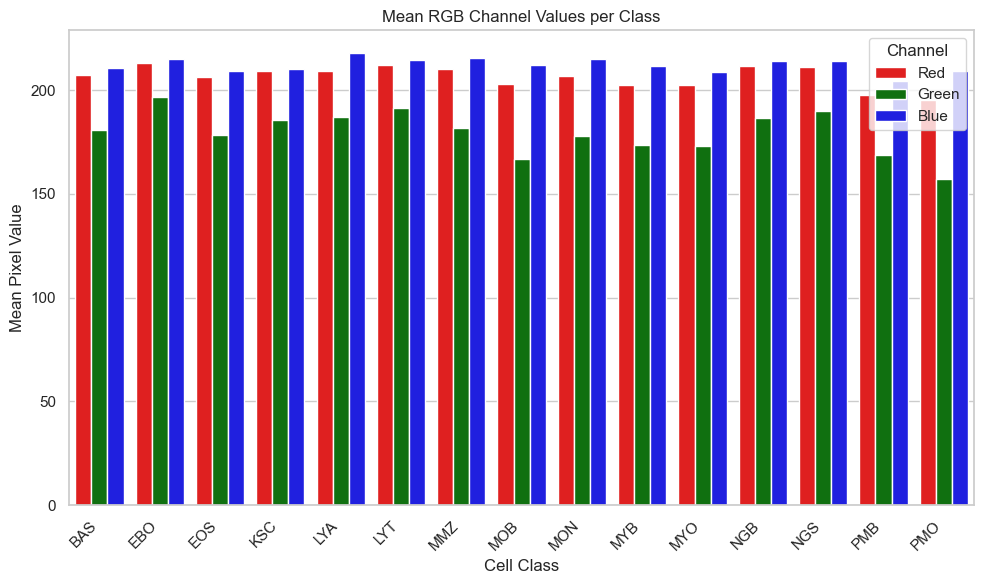

In [ ]:

df_long = pd.melt(
    df_rgb,
    id_vars="class",
    value_vars=["mean_r", "mean_g", "mean_b"],
    var_name="channel",
    value_name="mean_pixel_value"
)

df_long["channel"] = df_long["channel"].map(
    {"mean_r": "Red", "mean_g": "Green", "mean_b": "Blue"}
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="class",
    y="mean_pixel_value",
    hue="channel",
    palette=["red", "green", "blue"],
)
plt.title("Mean RGB Channel Values per Class")
plt.xlabel("Cell Class")
plt.ylabel("Mean Pixel Value")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Channel")
plt.tight_layout()
plt.show()

In [32]:
df.head()

,class,filename,mean_intensity,std_intensity,mean_r,std_r,min_r,max_r,mean_g,std_g,min_g,max_g,mean_b,std_b,min_b,max_b
0,KSC,KSC_0012.tiff,213.005875,38.237457,228.507095,21.992168,149.0,255.0,201.290405,52.108269,46.0,253.0,232.673447,11.105509,189.0,255.0
1,KSC,KSC_0003.tiff,211.189697,27.807699,224.746201,18.140066,172.0,255.0,204.122437,34.008923,112.0,255.0,212.023575,22.369751,135.0,255.0
2,KSC,KSC_0007.tiff,211.161057,50.343479,220.827072,33.123207,86.0,255.0,204.088318,65.862221,0.0,255.0,222.227356,20.016211,168.0,255.0
3,KSC,KSC_0014.tiff,210.029053,53.548668,222.742798,34.230228,89.0,255.0,200.336548,70.998466,0.0,247.0,226.591049,16.180443,169.0,248.0
4,KSC,KSC_0013.tiff,204.378128,50.390053,216.410126,34.258652,66.0,255.0,195.812302,65.382034,0.0,255.0,216.926956,21.371962,146.0,255.0


In [33]:
df_bc = df.groupby("class")[["mean_intensity", "std_intensity"]].agg("mean").reset_index()
df_bc.head()

,class,mean_intensity,std_intensity
0,BAS,192.060760,54.844837
1,EBO,203.688736,48.618744
2,EOS,190.304504,53.396626
3,KSC,195.431335,41.123775
4,LYA,197.193161,57.303837


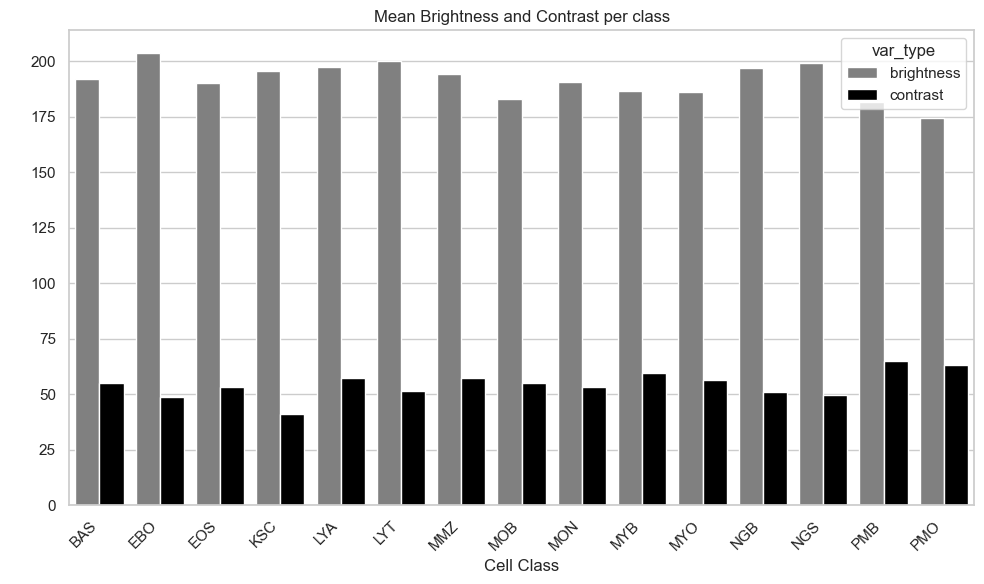

In [ ]:

df_long = pd.melt(
    df_bc,
    id_vars="class",
    value_vars=["mean_intensity", "std_intensity"],
    var_name="var_type",
    value_name="mean_pixel_value"
)

df_long["var_type"] = df_long["var_type"].map(
    {"mean_intensity": "brightness", "std_intensity": "contrast"}
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="class",
    y="mean_pixel_value",
    hue="var_type",
    palette=["grey", "black"],
)
plt.title("Mean Brightness and Contrast per class")
plt.xlabel("Cell Class")
plt.ylabel(" ")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()